**Predicting Loan Approval Decisions Using Machine Learning Classification Models**

- Overview

This project focuses on predicting loan approval status using machine learning techniques. The dataset contains applicant demographic, financial, employment, and credit-related information that can help determine whether a loan application is likely to be approved.

The objective is to build an intelligent classification model capable of assisting financial institutions in making faster, more consistent, and data-driven lending decisions.

In [1]:
# %pip install -q kagglehub seaborn bdp-model-gate scikit-learn matplotlib pandas numpy

In [2]:
# import kagglehub
# kagglehub.login()

#### **Requirement Gathering, Data Source**

In [3]:
import os
import kagglehub
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


# warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

%matplotlib inline

def show_layout():
    plt.figure(figsize=(9, 4))
    plt.tight_layout()
    plt.show()

/usr/local/python/3.14.2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Download latest version
path = kagglehub.dataset_download("muhammadmusharraf444/loan-approval-dataset")
source_path = path
destination_path = os.getcwd()

# Copy dataset from source directory to destination directory
source_path = path
destination_path = os.getcwd()

shutil.copytree(source_path, destination_path, dirs_exist_ok = True)

'/workspaces/bpd_gate_QA/notebooks'

In [5]:
source_path

'/home/codespace/.cache/kagglehub/datasets/muhammadmusharraf444/loan-approval-dataset/versions/1'

In [6]:
loan_df = pd.read_csv("./loan_data_new.csv")
loan_df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


#### **Dataset Overview**

In [7]:
print(f"Rows: {loan_df.shape[0]}, Columns: {loan_df.shape[1]}")
print(loan_df.columns.to_list())
print(loan_df.isna().sum())
print(loan_df.info())

Rows: 45000, Columns: 14
['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']
Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        4

In [8]:
print(f"{loan_df.duplicated().sum()} duplicate/s was found in this dataset")

0 duplicate/s was found in this dataset


#### **Cleaning and Standardization**

In [9]:
loan_df.columns = (loan_df.columns.str.strip().str.replace(" ", "_").str.lower())
loan_df = loan_df.rename(columns={"home_onwership": "home_ownership"})

# Identify columns with 'object' dtype (typically strings)
textual_cols = loan_df.select_dtypes(include='object').columns

for col in textual_cols:
    loan_df[col] = loan_df[col].str.lower()

In [10]:
# loan_df['loan_status'] = loan_df['loan_status'].map({"Yes": 1, "No": 0})

numerical_cols = loan_df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [col for col in loan_df.columns if col not in numerical_cols]

print(numerical_cols)
print(categorical_cols)

['age', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'loan_status']
['gender', 'education', 'home_ownership', 'loan_intent', 'previous_loan']


### **Univariate Analysis**

In [11]:
print("Summary statistics for numerical columns:")
print(loan_df[numerical_cols].describe().head())
print(loan_df[numerical_cols].isna().sum())

Summary statistics for numerical columns:
                age  person_income  employee_experience   loan_amount  \
count  45000.000000   45000.000000         45000.000000  45000.000000   
mean      27.764178   80319.053222             5.410333   9583.157556   
std        6.045108   80422.498632             6.063532   6314.886691   
min       20.000000    8000.000000             0.000000    500.000000   
25%       24.000000   47204.000000             1.000000   5000.000000   

       loan_interest_rate  loan_percentage  credit_history  credit_score  \
count        45000.000000     45000.000000    45000.000000  45000.000000   
mean            11.006606         0.139725        5.867489    632.608756   
std              2.978808         0.087212        3.879702     50.435865   
min              5.420000         0.000000        2.000000    390.000000   
25%              8.590000         0.070000        3.000000    601.000000   

        loan_status  
count  45000.000000  
mean       0.22222

In [12]:
loan_df[numerical_cols].describe().head()

,age,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,loan_status
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,80319.053222,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,80422.498632,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8000.000000,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,47204.000000,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000


In [13]:
numerical_summary = loan_df[numerical_cols].agg(["mean", "var", "std"])
numerical_summary

,age,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,loan_status
mean,27.764178,8.031905e+04,5.410333,9.583158e+03,11.006606,0.139725,5.867489,632.608756,0.222222
var,36.543333,6.467778e+09,36.766421,3.987779e+07,8.873299,0.007606,15.052086,2543.776478,0.172843
std,6.045108,8.042250e+04,6.063532,6.314887e+03,2.978808,0.087212,3.879702,50.435865,0.415744


In [14]:
print(loan_df[numerical_cols].skew()) # type: ignoreow
print(loan_df[numerical_cols].kurtosis()) # type: ignore

age                     2.548154
person_income          34.137583
employee_experience     2.594917
loan_amount             1.179731
loan_interest_rate      0.213784
loan_percentage         1.034512
credit_history          1.631720
credit_score           -0.610261
loan_status             1.336351
dtype: float64
age                      18.649449
person_income          2398.684769
employee_experience      19.168324
loan_amount               1.351215
loan_interest_rate       -0.420335
loan_percentage           1.082416
credit_history            3.725945
credit_score              0.203022
loan_status              -0.214176
dtype: float64


In [15]:
age_counts = loan_df["age"].value_counts().sort_index()
print(age_counts.head())

age
20      17
21    1289
22    4236
23    5254
24    5138
Name: count, dtype: int64


#### **Exploratory Data Analysis**

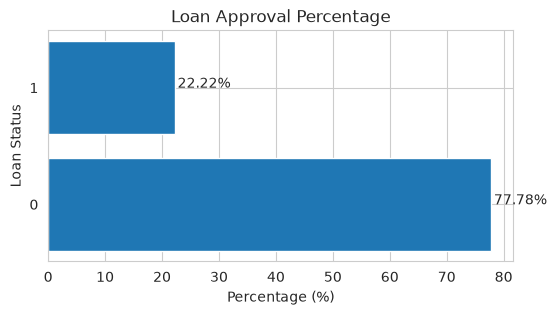

In [16]:
loan_approved_percentage = (
    loan_df['loan_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(6,3))
plt.barh(loan_approved_percentage.index.astype(str),
         loan_approved_percentage.values)

plt.xlabel('Percentage (%)')
plt.ylabel('Loan Status')
plt.title('Loan Approval Percentage')

for i, v in enumerate(loan_approved_percentage.values):
    plt.text(v + 0.5, i, f'{v:.2f}%')

plt.show()

# Highly imbalanced dataset, 78% of loan request were rejected whilst only 22% were accepted, since the model is right 78% of the time, it'll treat others as same (reject)

In [17]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

target_column = "loan_status"
log_numeric_cols = ["person_income", "loan_amount"]
plain_numeric_cols = ["employee_experience", "loan_interest_rate","loan_percentage", "credit_history", "credit_score"]
ordinal_cols = ["education"]
education_order = ["high school", "associate","bachelor", "master", "doctorate"]
binary_cols = ["previous_loan"]
nominal_cols = ["loan_intent", "home_ownership"]

X = loan_df[log_numeric_cols + plain_numeric_cols +
            ordinal_cols + binary_cols + nominal_cols]
y = loan_df[target_column]
protected_df = loan_df[["age", "gender"]]

X_train, X_val, y_train, y_val, prot_train, prot_val = train_test_split(
    X, y, protected_df, test_size=0.25, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("log_num", FunctionTransformer(np.log1p, validate=False), log_numeric_cols),
    ("plain_num", StandardScaler(), plain_numeric_cols),
    ("ordinal", OrdinalEncoder(categories=[education_order]), ordinal_cols),
    ("binary", OrdinalEncoder(), binary_cols),
    ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
])

In [19]:
pipeline = Pipeline([("preprocessor", preprocessor),
                     ("model", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                             eval_metric="logloss", random_state=42))])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict_proba(X_val)[:, 1]
print("Trained. Val shape:", X_val.shape)

Trained. Val shape: (11250, 11)


In [20]:
from bdp_model_gate import ModelGate, StructuredGateContext, GateConfig

model_card = {
    "use_case": "credit_scoring", "legal_basis": "Contractual necessity (NDPA 2023)",
    "data_minimization_justification": "Affordability signals only.",
    "training_data_source": "Internal loan dataset", "dpia_completed": False,
    "influences_decision_about_person": True, "explainability_method": "SHAP",
    "validation_strategy": "stratified_split",
}
context = StructuredGateContext(
    model=pipeline,
    X=X_val, 
    y_true=y_val, 
    y_pred=y_pred,
    protected_df=prot_val, 
    X_train=X_train, 
    model_card=model_card, 
    task="binary")

report = ModelGate().run(context)
print(report.summary())

shap could not explain this model: TypeError("unsupported operand type(s) for -: 'str' and 'str'")


Gate status: BLOCKED (89446ms, binary)
  roc_auc: 0.9766
  validation: 1 flag(s)
  performance: 0 flag(s)
  compliance: 1 flag(s)
  security: 0 flag(s)
  fairness: 4 flag(s)


In [21]:
display(
    pd.DataFrame(
        [
            {
                "category": r.category,
                "check": r.check_name,
                "flag": r.flag,
                "blocking": r.blocking,
                "ms": r.duration_ms,
                "detail": (r.detail[:62] + "...") if len(r.detail) > 62 else r.detail,
            }
            for r in report.results
        ]
    )
)

,category,check,flag,blocking,ms,detail
0,validation,target_leakage,OK,True,75.57,no single feature approaches the model's own p...
1,validation,split_overlap,OK,True,191.06,0 duplicate row(s) within the validation set (...
2,validation,split_overlap,OK,True,191.06,"0 of 11250 validation rows (0.0%, max 1%) also..."
3,validation,validation_strategy,VALIDATION_STRATEGY_RISK,True,0.03,credit_scoring is high-risk and was validated ...
4,validation,feature_contract,OK,True,0.05,X matches the 11 feature(s) recorded in model....
5,validation,feature_drift,OK,False,72.80,no drift above threshold across 11 shared feat...
6,fairness,proxy_correlation,OK,False,9143.40,no proxy correlations above threshold across 7...
7,fairness,disparate_impact,DISPARITY_RISK,False,1106.71,"age: demographic parity diff=1.000 [0.625, 1.0..."
8,fairness,disparate_impact,OK,False,1106.71,"gender: demographic parity diff=0.005 [0.000, ..."
9,fairness,shap_subgroup_gap,NOT_APPLICABLE,False,349.07,shap could not explain this model (TypeError: ...


In [22]:
from bdp_model_gate import PerformanceConfig
from bdp_model_gate.metrics import BUILTIN_METRICS
from bdp_model_gate.structured.performance import PerformanceThresholdCheck

rows = []
for name, spec in sorted(BUILTIN_METRICS.items()):
    if "binary" not in spec.tasks:
        continue
    result = PerformanceThresholdCheck(
        PerformanceConfig(metric=name, min_score=0.0)
    ).run(context)[0]
    rows.append({"metric": name, "value": result.metadata["value"],
                 "expects": "labels" if spec.needs_hard_labels else "scores"})
display(pd.DataFrame(rows).set_index("metric").sort_values("value", ascending=False))

,value,expects
metric,,
roc_auc,0.9766,scores
average_precision,0.9349,scores
accuracy,0.9316,labels
precision,0.8943,labels
balanced_accuracy,0.8793,labels
f1,0.8362,labels
recall,0.7852,labels


**Validate Each Metric across Different Threshold (default_threshold)**

So Dumininu, by default the `decision_threshold` is set to 0.5 for binarised targets (hence equal share for both class, 50%). Also the value should makes sense relative to the specific metric. PerformanceThresholdCheck is 0.5, which means that any metric value below 0.5 will be flagged as a failure. You can adjust this threshold by passing a different value to the PerformanceConfig when creating the check.

avoid `roc-auc`. cause if you pick `roc_auc`, `decision_threshold` setting is irrelevant, since it answer an entirely differnt question, so it never gets used. If you pick `precision or recall`, changing decision_threshold from 0.5 to, say, 0.3 will change the score, because it changes how many predictions get called "default" in the first place.

In [23]:
from bdp_model_gate import PerformanceConfig
from bdp_model_gate.structured.performance import PerformanceThresholdCheck

sweep = []
for threshold in (0.3, 0.4, 0.5, 0.6, 0.7):
    row = {"decision_threshold": threshold}
    for name in ('precision', 'recall', 'f1', "roc_auc"):
        cfg = PerformanceConfig(metric=name, min_score=0.0, decision_threshold = threshold)
        row[name] = PerformanceThresholdCheck(cfg).run(context)[0].metadata["value"]
    sweep.append(row)
display(pd.DataFrame(sweep).set_index("decision_threshold").round(4))


,precision,recall,f1,roc_auc
decision_threshold,,,,
0.3,0.7722,0.8880,0.8260,0.9766
0.4,0.8424,0.8360,0.8392,0.9766
0.5,0.8943,0.7852,0.8362,0.9766
0.6,0.9320,0.7348,0.8217,0.9766
0.7,0.9556,0.6808,0.7951,0.9766


**Weighting Precision over Recall using f2**

In [24]:
from sklearn.metrics import fbeta_score

def f2_at_30pct(y_true, y_pred):
    return fbeta_score(y_true, (np.asarray(y_pred) >= 0.30).astype(int), beta=2)


result = PerformanceThresholdCheck(
    PerformanceConfig(metric=f2_at_30pct, min_score=0.85)
).run(context)[0]
print(f"{result.flag:18} {result.detail}")
print("reported as:", result.metadata["metric"])   # from the function __name__

OK                 f2_at_30pct=0.8621 [0.851, 0.872] (min 0.85) — the whole interval sits above 0.850
reported as: f2_at_30pct


In [25]:
# from unittest import mock

# import bdp_model_gate.metrics as metrics_module
# from bdp_model_gate.exceptions import GateConfigurationError

# # Simulate a core-only install (no scikit-learn) without uninstalling.
# with mock.patch.object(metrics_module, "_load_sklearn_metric", return_value=None):
#     auto = PerformanceThresholdCheck(
#         PerformanceConfig(metric="auto", min_score=0.80)
#     ).run(context)[0]
#     print("auto fell back to :", auto.metadata["metric"])
#     print("flagged as fallback:", auto.metadata["metric_is_fallback"])
#     print("detail             :", auto.detail)

#     # An explicitly named metric is never swapped for another.
#     try:
#         PerformanceThresholdCheck(PerformanceConfig(metric="roc_auc")).run(context)
#     except GateConfigurationError as exc:
#         print("\nexplicit metric unavailable ->", exc)

In [26]:
# for r in report.results:
#     if r.category =="fairness":
#         print(f"{r.check_name:30} {r.flag:10} {r.detail}")

for r in report.by_category("fairness"):
    print(f"{' 'if r.is_ok else '->'} {r.check_name:22} {r.flag}")
    print(f"    {r.detail}")

  proxy_correlation      OK
    no proxy correlations above threshold across 7 comparison(s)
-> disparate_impact       DISPARITY_RISK
    age: demographic parity diff=1.000 [0.625, 1.000] at 95% (max 0.1) — the whole 95% interval sits above 0.100
  disparate_impact       OK
    gender: demographic parity diff=0.005 [0.000, 0.020] at 95% (max 0.1) — the whole interval sits below 0.100
  shap_subgroup_gap      NOT_APPLICABLE
    shap could not explain this model (TypeError: unsupported operand type(s) for -: 'str' and 'str') — subgroup SHAP gaps were not evaluated
  counterfactual_flip    NOT_APPLICABLE
    no protected attributes present as model inputs
-> equalised_odds         EQUAL_OPPORTUNITY_RISK
    age: true-positive-rate difference=0.417 [0.312, 0.923] at 95% (max 0.1) — among those who should be approved, 43 is least likely to be — the whole 95% interval sits above 0.100
-> equalised_odds         EQUALISED_ODDS_RISK
    age: equalised odds difference=0.417 [0.312, 0.923] at 95%

In [27]:
# %pip install -q bdp-model-gate[full]
# %pip install -q bdp-model-gate[structured]

In [28]:
# for r in report.by_category("fairness"):
#     print(f"{' 'if r.is_ok else '->'} {r.check_name:22} {r.flag}")
#     print(f"    {r.detail}")

In [ ]:
from bdp_model_gate import FairnessConfig
from bdp_model_gate.structured.fairness import DisparateImpactCheck, ProxyCorrelationCheck
from bdp_model_gate.structured.calibration_checks import (
    CalibrationCheck,
    EqualisedOddsCheck,
    SubgroupCalibrationCheck,
)

FAMILY = {
    "disparate_impact": "independence",
    "equalised_odds": "separation",
    "subgroup_calibration": "sufficiency",
}

for check in (DisparateImpactCheck(), EqualisedOddsCheck(), SubgroupCalibrationCheck()):
    for r in check.run(context):
        if r.metadata.get("protected_attr") != "region":
            continue
        print(f"{FAMILY[r.check_name]:14} {r.flag:26} {r.detail[:74]}")